# Imports

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy

In [2]:
class_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball',
               'cricket_ball', 'football', 'golf_ball', 'hockey_ball', 'hockey_puck',
               'rugby_ball', 'shuttlecock', 'table_tennis_ball', 'tennis_ball', 'volleyball']

TRAIN_DIR = r'C:\Users\cuent\Desktop\Semana 3 Redes Neuronales\Semana 4\train\train'
TEST_DIR = r'C:\Users\cuent\Desktop\Semana 3 Redes Neuronales\Semana 4\test\test'

n_images = [len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names]
px.pie(names=class_names, values=n_images, title='Distribución de clases (Train)')

In [3]:
# Contar imágenes por categoría y conjunto
train_counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in class_names}
test_counts = {c: len(os.listdir(os.path.join(TEST_DIR, c))) for c in class_names}

total_train = sum(train_counts.values())
total_test = sum(test_counts.values())
total_all = total_train + total_test

print("=== Conjunto de Entrenamiento ===")
for c, n in train_counts.items():
    print(f"  {c}: {n} imágenes")
print(f"Total Training: {total_train} imágenes ({(total_train/total_all)*100:.2f}%)\n")

print("=== Conjunto de Test ===")
for c, n in test_counts.items():
    print(f"  {c}: {n} imágenes")
print(f"Total Test: {total_test} imágenes ({(total_test/total_all)*100:.2f}%)\n")

print(f"Total Imágenes: {total_all}")

=== Conjunto de Entrenamiento ===
  american_football: 384 imágenes
  baseball: 400 imágenes
  basketball: 340 imágenes
  billiard_ball: 646 imágenes
  bowling_ball: 440 imágenes
  cricket_ball: 581 imágenes
  football: 604 imágenes
  golf_ball: 549 imágenes
  hockey_ball: 530 imágenes
  hockey_puck: 390 imágenes
  rugby_ball: 493 imágenes
  shuttlecock: 429 imágenes
  table_tennis_ball: 620 imágenes
  tennis_ball: 490 imágenes
  volleyball: 432 imágenes
Total Training: 7328 imágenes (79.92%)

=== Conjunto de Test ===
  american_football: 96 imágenes
  baseball: 100 imágenes
  basketball: 86 imágenes
  billiard_ball: 162 imágenes
  bowling_ball: 111 imágenes
  cricket_ball: 146 imágenes
  football: 151 imágenes
  golf_ball: 138 imágenes
  hockey_ball: 133 imágenes
  hockey_puck: 98 imágenes
  rugby_ball: 124 imágenes
  shuttlecock: 108 imágenes
  table_tennis_ball: 156 imágenes
  tennis_ball: 123 imágenes
  volleyball: 109 imágenes
Total Test: 1841 imágenes (20.08%)

Total Imágenes: 91

In [4]:
# Generadores de datos para entrenamiento y test.
# Estos generadores permiten cargar imágenes desde disco y aplicarles un reescalado para normalizar los valores de los píxeles entre 0 y 1.

train_gen = ImageDataGenerator(
    rescale=1./255)  # Generador para el conjunto de entrenamiento

test_gen = ImageDataGenerator(
    rescale=1./255)  # Generador para el conjunto de test

In [5]:
# Crea un generador de datos para el conjunto de entrenamiento.
train_generator = train_gen.flow_from_directory(
    TRAIN_DIR,               # Directorio raíz donde están las 15 carpetas de balones para entrenamiento.
    target_size=(150, 150),  # Redimensiona todas las imágenes a 150x150 píxeles.
    batch_size=64,           # Número de imágenes que se cargarán en cada lote (batch).
    class_mode='categorical' # Etiquetado categórico: one-hot encoding para 15 clases.
)

# Crea un generador de datos para el conjunto de test.
test_generator = test_gen.flow_from_directory(
    TEST_DIR,                # Directorio raíz donde están las 15 carpetas de balones para test.
    target_size=(150, 150),  # Redimensiona todas las imágenes a 150x150 píxeles.
    batch_size=64,           # Número de imágenes por lote.
    class_mode='categorical' # Etiquetado categórico.
)

Found 7328 images belonging to 15 classes.


Found 1841 images belonging to 15 classes.


In [6]:
def plot_data(generator, n_images):
    """
    Muestra imágenes aleatorias de un generador de datos de imágenes junto con su etiqueta.

    Parámetros:
    -----------
    generator : DirectoryIterator
        Instancia de un generador de imágenes (por ejemplo, generado por flow_from_directory).
    n_images : int
        Número de imágenes a mostrar.
    """

    i = 1
    images, labels = next(generator)
    labels = np.argmax(labels, axis=1)  # Convierte one-hot a índice de clase

    plt.figure(figsize=(14, 15))
    
    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == n_images:
            break

    plt.show()

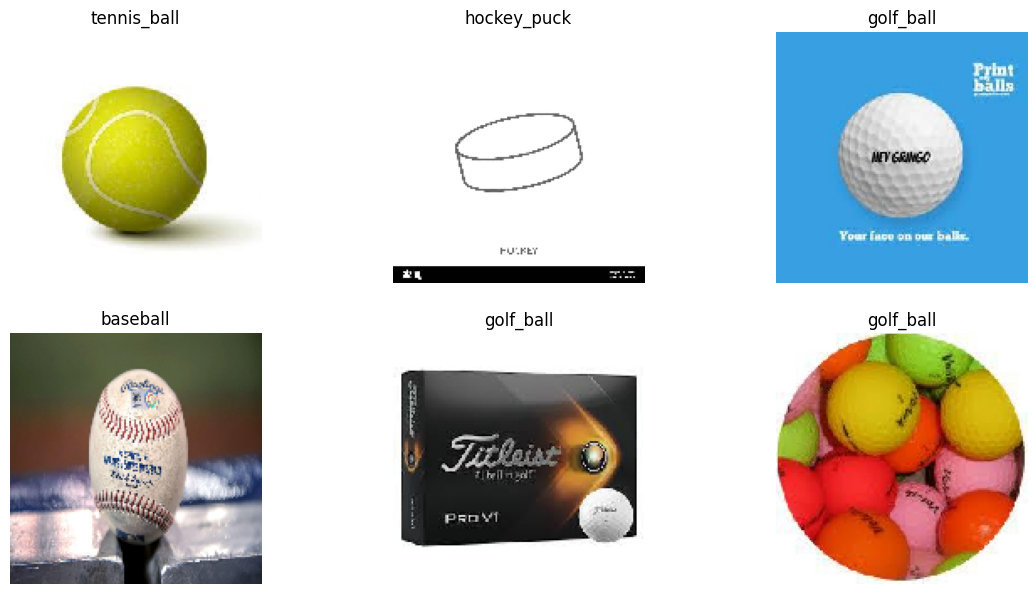

In [7]:
plot_data(train_generator, 7)

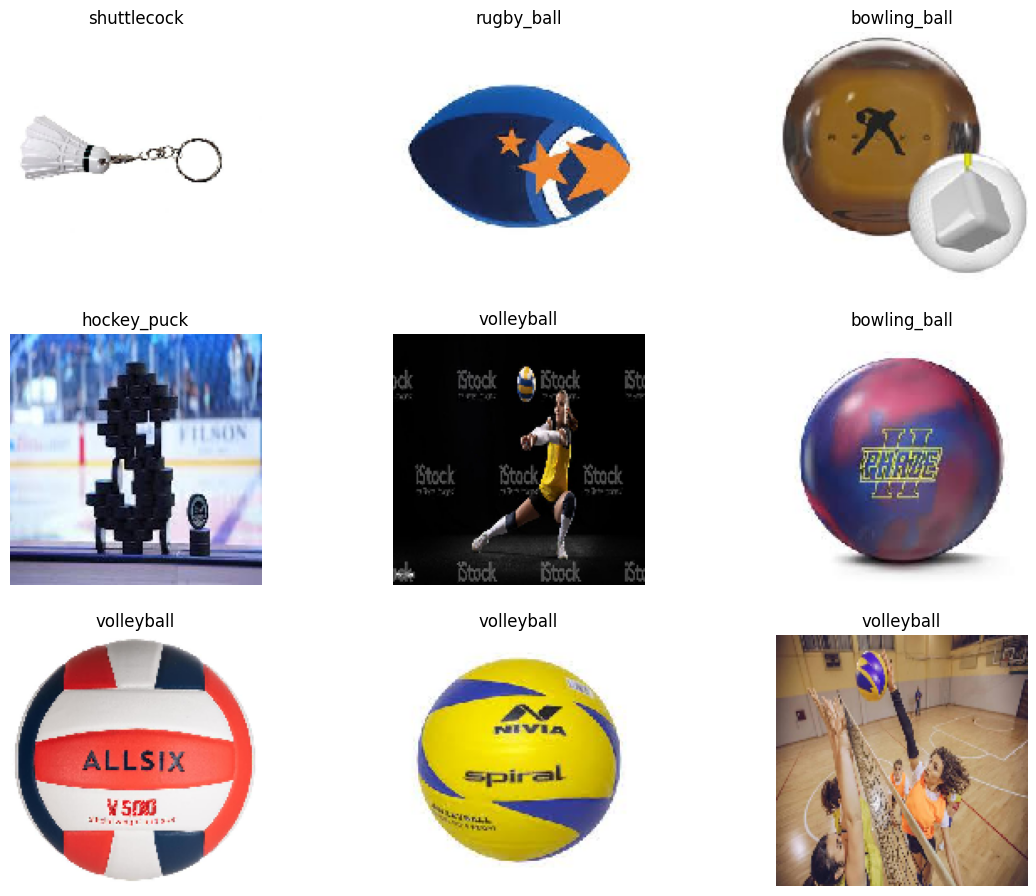

In [8]:
plot_data(test_generator, 10)

# MODELO

# Definición del modelo de red neuronal convolucional (CNN) para clasificación multiclase (15 tipos de balones)

---

## ¿Qué hace este código?

- Define la arquitectura de un modelo CNN usando **Keras Functional API**.
- El modelo toma imágenes de tamaño `150x150x3` (RGB) y predice a cuál de las 15 clases de balones pertenece.
- Utiliza varias capas **convolucionales** para extraer características, seguidas de capas **densas** para la clasificación.
- La salida es una capa `softmax` de **15 neuronas** (una para cada clase de balón).

---

## Estructura del modelo

- **Entrada:**  
  `Input(shape=(150, 150, 3))`

- **Capas ocultas:**  
  `Conv2D`, `MaxPooling2D`, `GlobalAveragePooling2D`, y capas `Dense` intermedias.

- **Salida:**  
  `Dense(15, activation='softmax')`

In [9]:
inputs = tf.keras.layers.Input(shape=(150,150,3))  # Capa de entrada: imágenes RGB de 150x150 píxeles

# Capas ocultas convolucionales y de pooling para extraer características
x = tf.keras.layers.Conv2D(32, (3,3), activation='relu')(inputs) #Detectar patrones básicos (bordes, colores, texturas).
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x) #Aumentamos a 64 filtros para extraer patrones más complejos.
x = tf.keras.layers.MaxPooling2D(2,2)(x)# Reduce la dimensión (submuestreo) conservando la info más importante.

# Segundo bloque convolucional
x = tf.keras.layers.Conv2D(64, (3,3), activation='relu')(x)# Otra capa para aprender características más profundas.
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x) #Aumenta a 128 filtros para patrones más complejos aún.
x = tf.keras.layers.MaxPooling2D(2,2)(x) #Otra reducción del tamaño de imagen para concentrar los datos.

#Tercer bloque convolucional
x = tf.keras.layers.Conv2D(128, (3,3), activation='relu')(x)
x = tf.keras.layers.Conv2D(256, (3,3), activation='relu')(x)

#GlobalAveragePooling2D: promedio global de cada mapa de activación.
x = tf.keras.layers.GlobalAveragePooling2D()(x)  

#Capa densa (fully connected) con 1024 neuronas.
x = Dense(1024, activation='relu')(x)

# Capa de salida: 15 neuronas (una por cada tipo de balón) con softmax para obtener probabilidades
x = tf.keras.layers.Dense(15, activation='softmax')(x)

# Definición del modelo final
model = Model(inputs=inputs, outputs=x)

In [10]:
# Compila el modelo antes de entrenarlo.
model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),  # Optimizador RMSprop con tasa de aprendizaje 0.001.
    loss='categorical_crossentropy',  # Función de pérdida para clasificación multiclase con etiquetas one-hot.
    metrics=['accuracy']  # Métrica a monitorear durante el entrenamiento y validación.
)

### Importante: si queremos que mejore el modelo podemos aumentar las épocas pero eso elevará el consumo computacional

In [11]:
# Entrena el modelo usando los datos de entrenamiento y valida con el conjunto de test.
r = model.fit(
        train_generator,
        epochs=10,  # Entrenar por más épocas puede mejorar los resultados
        validation_data=test_generator  # Validación en cada época
)

Epoch 1/10


  1/115 ━━━━━━━━━━━━━━━━━━━━ 5:32 3s/step - accuracy: 0.0156 - loss: 2.7057

  2/115 ━━━━━━━━━━━━━━━━━━━━ 2:21 1s/step - accuracy: 0.0547 - loss: 2.6988

  3/115 ━━━━━━━━━━━━━━━━━━━━ 2:25 1s/step - accuracy: 0.0608 - loss: 2.7384

  4/115 ━━━━━━━━━━━━━━━━━━━━ 2:26 1s/step - accuracy: 0.0680 - loss: 2.7513

...

112/115 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - accuracy: 0.3667 - loss: 1.9897 

113/115 ━━━━━━━━━━━━━━━━━━━━ 5s 3s/step - accuracy: 0.3667 - loss: 1.9896

114/115 ━━━━━━━━━━━━━━━━━━━━ 2s 3s/step - accuracy: 0.3668 - loss: 1.9896

115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3668 - loss: 1.9895

115/115 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step - accuracy: 0.3712 - loss: 1.9794 - val_accuracy: 0.3341 - val_loss: 2.1448


# Evaluation

## Evaluate the model on the test set

In [12]:
# Evalúa el modelo en el conjunto de test.
model.evaluate(test_generator)

 1/29 ━━━━━━━━━━━━━━━━━━━━ 25s 894ms/step - accuracy: 0.3281 - loss: 2.3067

 2/29 ━━━━━━━━━━━━━━━━━━━━ 14s 531ms/step - accuracy: 0.3359 - loss: 2.2366

 3/29 ━━━━━━━━━━━━━━━━━━━━ 13s 509ms/step - accuracy: 0.3368 - loss: 2.2037

 4/29 ━━━━━━━━━━━━━━━━━━━━ 12s 517ms/step - accuracy: 0.3317 - loss: 2.1914

 5/29 ━━━━━━━━━━━━━━━━━━━━ 12s 516ms/step - accuracy: 0.3297 - loss: 2.1828

...

27/29 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step - accuracy: 0.3389 - loss: 2.1467

28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.3388 - loss: 2.1465

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.3386 - loss: 2.1465

29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 507ms/step - accuracy: 0.3341 - loss: 2.1448


[2.1447501182556152, 0.3340575695037842]

## Visualize the predictions

In [13]:
def plot_prediction(generator, n_images):
    """
    Muestra imágenes aleatorias del generador junto con la predicción del modelo y la etiqueta real.
    Si la predicción es correcta, el título es verde; si es incorrecta, es rojo.

    Parámetros:
    -----------
    generator : DirectoryIterator
        Generador de imágenes (por ejemplo, generado por flow_from_directory).
    n_images : int
        Número de imágenes a mostrar.
    """

    i = 1
    images, labels = next(generator)

    preds = model.predict(images)
    predictions = np.argmax(preds, axis=1)
    labels_idx = np.argmax(labels, axis=1)  # Convierte one-hot a índice de clase

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels_idx):
        plt.subplot(4, 3, i)
        plt.imshow(image)

        if predictions[i-1] == label:
            title_obj = plt.title(f"Real: {class_names[label]}\nPred: {class_names[predictions[i-1]]}")
            plt.setp(title_obj, color='g')
            plt.axis('off')
        else:
            title_obj = plt.title(f"Real: {class_names[label]}\nPred: {class_names[predictions[i-1]]}")
            plt.setp(title_obj, color='r')
            plt.axis('off')

        i += 1

        if i == n_images:
            break

    plt.show()

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 271ms/step


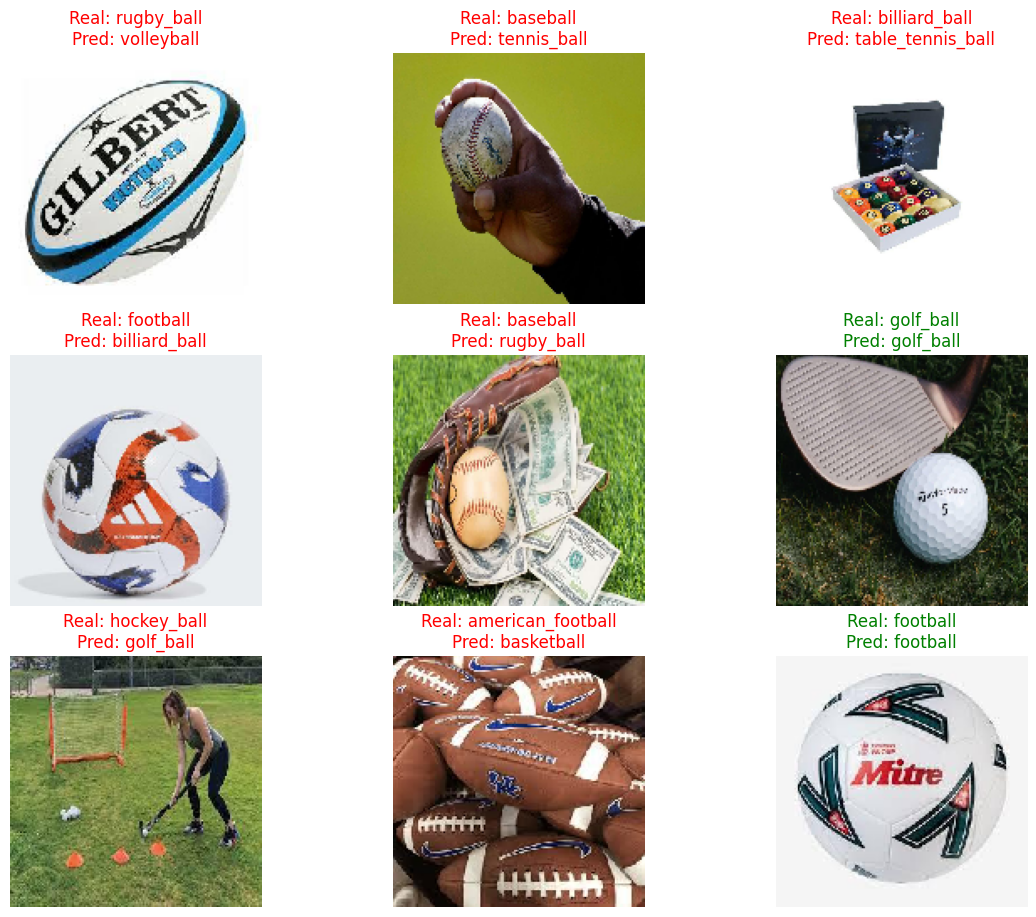

In [14]:
# Muestra 10 imágenes del test set con su predicción y etiqueta real.
plot_prediction(test_generator, 10)

# Visualize class activation maps

In [15]:
# Obtiene los pesos de la capa densa (fully connected) antes de la salida.
gp_weights = model.get_layer('dense').get_weights()[0]

# Crea un modelo intermedio para extraer activaciones de la última capa convolucional
# y la capa densa de salida para visualizar los mapas de activación.
activation_model = Model(model.inputs, outputs=(model.get_layer('conv2d_5').output, model.get_layer('dense_1').output))

In [16]:
# Usa el modelo para hacer predicciones sobre un lote del generador de test
images, _ = next(test_generator)  # Obtiene un lote de imágenes del conjunto de test
features, results = activation_model.predict(images)  # Extrae las activaciones y predicciones

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 369ms/step


In [17]:
def show_cam(image_index, features, results):
    """
    Visualiza el mapa de activación de clase (Class Activation Map, CAM) para una imagen específica.
    """
    features_for_img = features[image_index,:,:,:]
    prediction = np.argmax(results[image_index])
    class_activation_weights = gp_weights[:,prediction]
    class_activation_features = sp.ndimage.zoom(features_for_img, (150/30, 150/30, 1), order=2)
    cam_output = np.dot(class_activation_features, class_activation_weights)

    print('Predicted Class = ' + str(class_names[prediction]) + ', Probability = ' + str(results[image_index][prediction]))

    plt.imshow(images[image_index])

    if results[image_index][prediction] > 0.95:
        cmap_str = 'Greens'
    else:
        cmap_str = 'Blues'

    plt.imshow(cam_output, cmap=cmap_str, alpha=0.5)
    plt.show()

In [18]:
def show_maps(desired_class, num_maps):
    """
    Recorre las imágenes de test y genera mapas de activación CAM para una clase específica.
    """
    counter = 0
    for i in range(0, len(images)):
        if counter == num_maps:
            break
        if np.argmax(results[i]) == desired_class:
            counter += 1
            show_cam(i, features, results)

=== CAM para football (clase 6) ===


Predicted Class = football, Probability = 0.1980047


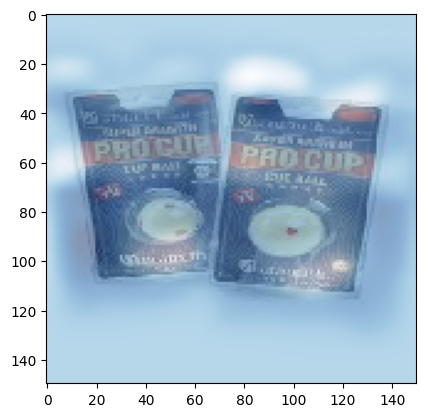

Predicted Class = football, Probability = 0.17786264


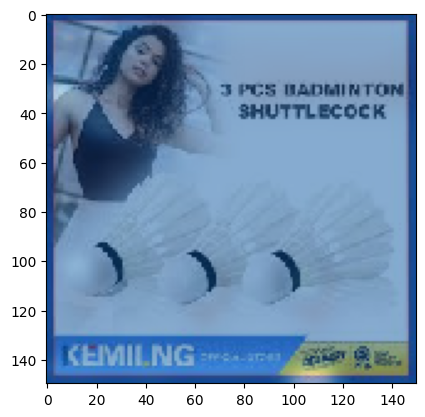

Predicted Class = football, Probability = 0.26447356


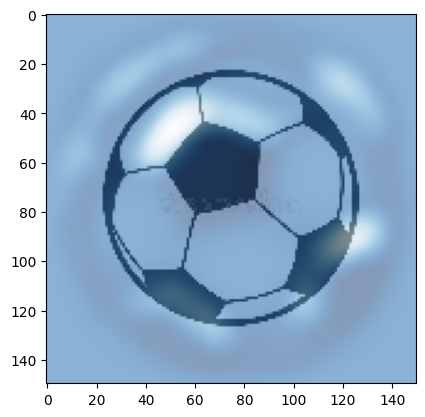


=== CAM para basketball (clase 2) ===


Predicted Class = basketball, Probability = 0.35323203


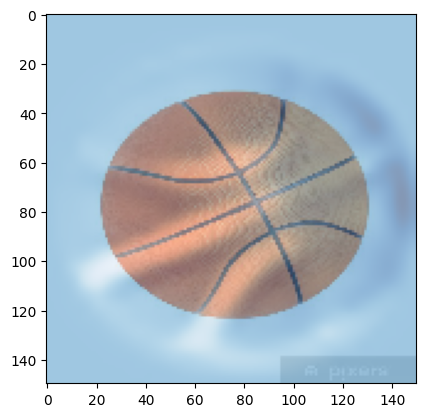

Predicted Class = basketball, Probability = 0.48864347


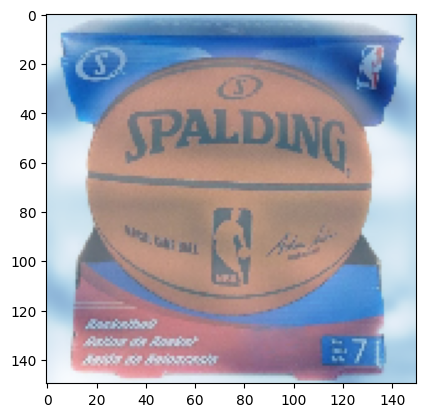


=== CAM para tennis_ball (clase 13) ===


Predicted Class = tennis_ball, Probability = 0.80731285


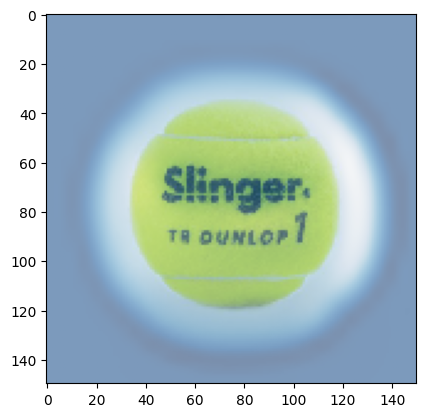

Predicted Class = tennis_ball, Probability = 0.8387593


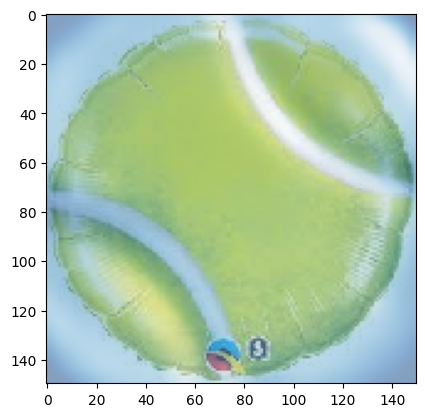

Predicted Class = tennis_ball, Probability = 0.62919354


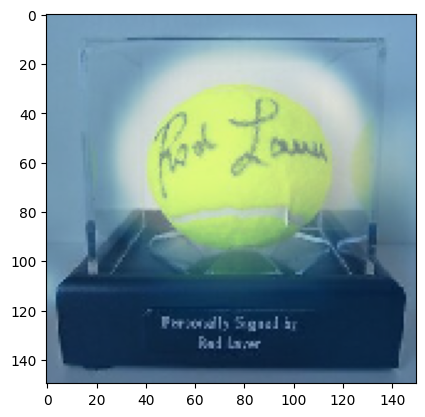

In [19]:
# Mostrar CAMs para algunas clases representativas
print("=== CAM para football (clase 6) ===")
show_maps(desired_class=6, num_maps=3)

print("\n=== CAM para basketball (clase 2) ===")
show_maps(desired_class=2, num_maps=3)

print("\n=== CAM para tennis_ball (clase 13) ===")
show_maps(desired_class=13, num_maps=3)

## Visualize training process

In [20]:
results_df = pd.DataFrame(r.history)
results_df.tail()

,accuracy,loss,val_accuracy,val_loss
5,0.286572,2.232378,0.313417,2.188641
6,0.306632,2.168898,0.300380,2.223779
7,0.334607,2.082535,0.353069,2.047719
8,0.348663,2.031208,0.349810,2.048060
9,0.371179,1.979370,0.334058,2.144750


In [21]:
fig = px.line(results_df, y=[results_df['accuracy'], results_df['val_accuracy']], template="seaborn", color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a", title='Epochs'), 
    yaxis=dict(color="#fad25a")
)
fig.show()

In [22]:
fig = px.line(results_df, y=[results_df['loss'], results_df['val_loss']], template="seaborn", color_discrete_sequence=['#fad25a','red'])
fig.update_layout(   
    title_font_color="#fad25a", 
    xaxis=dict(color="#fad25a", title='Epochs'), 
    yaxis=dict(color="#fad25a")
)
fig.show()